In [21]:
import numpy as np
import tensorflow.keras as tf
import matplotlib.pyplot as plt

In [22]:
class ActivationFunction:

  def __init__(self, func, deriv_func=None, name=""):

    self.func = func
    self.deriv_func = deriv_func
    self.name = name

  def apply(self, X):

    return self.func(X)

  def apply_deriv(self, X):

    return self.deriv_func(X)

class Layer:

  def __init__(self, num_units=1, activation_func=None):

    self.num_units = num_units if num_units > 0 else 1
    self.activation_func = activation_func

    self.W = None
    self.b = None

  def feed(self, inputs):

    linear_output = (self.W @ inputs) + self.b

    activated_output = linear_output

    if self.activation_func:

      activated_output = self.activation_func.apply(linear_output)

    return [linear_output, activated_output]

class NeuralNetwork:

  def __init__(self, layers, input_dim=None, lr=0.1, eval_func=None):

    self.layers=layers
    self.lr = lr
    self.eval_func = eval_func
    self.input_dim = input_dim

    prev_shape = input_dim
    for layer in self.layers:

      layer.W = np.random.randn(layer.num_units, prev_shape) * 0.01
      layer.b = np.zeros((layer.num_units, 1))
      prev_shape = layer.num_units

  def get_architecture(self):

    print("====Neural Network Architecture=================")

    for i, layer in enumerate(self.layers):

      if layer.activation_func:
        print(f"Layer {i+1}:\n  Units: {layer.num_units}\n  Output Shape: {(layer.num_units, 1)}\n  Activation Function: {layer.activation_func.name}\n")
      else:
        print(f"Layer {i+1}:\n  Units: {layer.num_units}\n  Output Shape: {(layer.num_units, 1)}\n")

    print("================================================")


  def feed_forward(self, X):

    output = X
    inputs = []
    outputs = []

    for layer in self.layers:

      inputs.append(output)

      linear_output, activated_output = layer.feed(output)

      outputs.append([linear_output, activated_output])

      output = activated_output

    return output, inputs, outputs

  def back_propagation(self, inputs, outputs, y_true, y_hat):

    gradients = []

    num_layers = len(self.layers)

    curr_grad = -2 * (y_true - y_hat)

    for i in reversed(range(num_layers)):

      if self.layers[i].activation_func:

        curr_grad = curr_grad * self.layers[i].activation_func.apply_deriv(outputs[i][0])

      curr_grad_W, curr_grad_b = (1/inputs[i].shape[1]) * curr_grad @ inputs[i].T , (1/inputs[i].shape[1]) * np.sum(curr_grad, axis=1, keepdims=True)

      curr_grad = self.layers[i].W.T @ curr_grad

      gradients.append([curr_grad_W.copy(), curr_grad_b.copy()])

    return gradients[::-1]

  def update_weights(self, gradients):

    for i in range(len(self.layers)):

      W, b = gradients[i][0], gradients[i][1]

      self.layers[i].W -= self.lr*W
      self.layers[i].b -= self.lr*b


  def evaluate(self, y_true, y_hat):

    return self.eval_func.apply(y_true, y_hat)



In [23]:
inputs = np.random.randn(10, 100)
lbls = inputs[0] * (3/9) + inputs[1] **2
lbls = np.reshape(lbls, (1, -1))
inputs.shape, lbls.shape

((10, 100), (1, 100))

In [24]:
def RELU(X):

  return np.maximum(0, X).astype(float)

def deriv_RELU(X):

  return (X > 0).astype(float)

def root_mean_squared_error(y_true, y_hat):

  return np.sqrt(np.sum((y_true - y_hat)**2))

def mean_squared_error(y_true, y_hat):

  return np.sum((y_true - y_hat)**2)

def deriv_mean_squared_error(y_true, y_hat):

  return -2 * np.sum(y_true - y_hat)

====Neural Network Architecture=================
Layer 1:
  Units: 10
  Output Shape: (10, 1)
  Activation Function: RELU

Layer 2:
  Units: 8
  Output Shape: (8, 1)
  Activation Function: RELU

Layer 3:
  Units: 6
  Output Shape: (6, 1)
  Activation Function: RELU

Layer 4:
  Units: 4
  Output Shape: (4, 1)
  Activation Function: RELU

Layer 5:
  Units: 2
  Output Shape: (2, 1)
  Activation Function: RELU

Layer 6:
  Units: 1
  Output Shape: (1, 1)



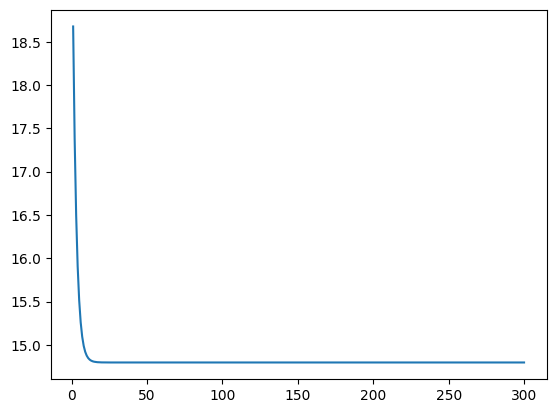

In [25]:
relu_actv = ActivationFunction(RELU, deriv_RELU, "RELU")
mse_actv = ActivationFunction(mean_squared_error, deriv_mean_squared_error, "Mean Squared Error")

sequence = [
    Layer(10, activation_func=relu_actv),
    Layer(8, activation_func=relu_actv),
    Layer(6, activation_func=relu_actv),
    Layer(4, activation_func=relu_actv),
    Layer(2, activation_func=relu_actv),
    Layer(1)
]

nn = NeuralNetwork(sequence, eval_func=mse_actv, input_dim=inputs.shape[0], lr=0.1)
nn.get_architecture()


n_epochs = 300
losses = []

for epochs in range(n_epochs):

  out, ins, outs = nn.feed_forward(inputs)
  loss = root_mean_squared_error(lbls, out)
  gradients = nn.back_propagation(ins, outs, lbls, out)
  nn.update_weights(gradients)

  losses.append(loss)


plt.plot(np.arange(1, n_epochs+1), losses)